A Beginner's Guide to Reinforcement Learning on Grid World with Q-Learning

In [1]:
%reset -f

## Environment

In [2]:
# Base Environment class
class Environment:
    def reset(self):
        """Defines the entire state space.

        Is a given within an environment static, i.e. it doesn't change from episode to episode, then this given isn't a state variable. Otherwise, is a given within an
        environment dynamic, i.e. it changes from episode to episode, then this given has to be modeled as a state variable and is part of the entire state space. A dynamic given
        can be observed via its uncertainty.
        """
        self.state = None
        return self.state

    def step(self, action):
        """Defines the next state and reward regarding to an action at current state."""
        reward, done = None, False
        return reward, done

In [3]:
from dataclasses import dataclass, field
from typing import Dict, List, Tuple

@dataclass
class TerrainCosts:
    """Kosten für verschiedene Terrain-Typen"""
    free: float
    river: float
    swamp: float
    mountain: float
    
    def to_dict(self) -> Dict[str, float]:
        """Konvertiert zu Dictionary für Kompatibilität"""
        return {
            'free': self.free,
            'river': self.river,
            'swamp': self.swamp,
            'mountain': self.mountain
        }

@dataclass
class ObstacleConfig:
    """Konfiguration für Hindernisse im Grid"""
    river_positions: List[Tuple[int, int]]
    swamp_positions: List[Tuple[int, int]]
    mountain_positions: List[Tuple[int, int]]
    
    def to_dict(self) -> Dict[str, List[Tuple[int, int]]]:
        """Konvertiert zu Dictionary für GridEnvironment"""
        return {
            "river": self.river_positions,
            "swamp": self.swamp_positions,
            "mountain": self.mountain_positions
        }
    
    def total_count(self) -> int:
        """Gibt die Gesamtanzahl aller Hindernisse zurück"""
        return len(self.river_positions) + len(self.swamp_positions) + len(self.mountain_positions)

@dataclass
class GridConfig:
    """Konfiguration für das Grid Environment"""
    shape: Tuple[int, int]
    start_position: Tuple[int, int]
    goal_position: Tuple[int, int]
    obstacles: ObstacleConfig

@dataclass
class RewardConfig:
    """Reward-Konfiguration"""
    goal_reward: float
    terrain_costs: TerrainCosts

@dataclass
class TrainingConfig:
    """Hyperparameter für Q-Learning Training"""
    episodes: int
    alpha: float
    gamma: float
    epsilon_start: float
    epsilon_min: float
    max_steps: int
    verbose: bool

In [4]:
# Flüsse - verlaufen hauptsächlich diagonal/horizontal durch die Karte
river_positions = [
    # Fluss 1 - diagonal von oben links nach unten
    (2, 5), (3, 6), (4, 7), (5, 8), (6, 9), (7, 10), (8, 11), (9, 11),
    # Fluss 2 - horizontal in der Mitte
    (12, 8), (12, 9), (12, 10), (12, 11), (12, 12), (12, 13), (12, 14), (12, 15),
    # Fluss 3 - vertikal auf der rechten Seite
    (4, 18), (5, 18), (6, 18), (7, 18), (8, 18), (9, 18), (10, 18), (11, 18),
    # Fluss 4 - zusätzlicher Fluss unten
    (20, 8), (20, 9), (20, 10), (20, 11), (21, 11), (21, 12), (21, 13),
    # Kleinere Flussarme
    (15, 5), (15, 6), (16, 6), (17, 7), (18, 7), (18, 8),
    # Weitere Flussabschnitte
    (6, 15), (7, 16), (8, 17), (9, 17),
    (14, 18), (14, 19), (15, 19), (16, 20)
]

# Moore - in feuchten Niederungen nahe Flüssen
swamp_positions = [
    # Moor-Gebiet 1 - neben Fluss 1
    (3, 5), (4, 5), (4, 6), (5, 7), (6, 8), (7, 9), (8, 10),
    (9, 10), (9, 12), (8, 12), (10, 11), (10, 12),
    # Moor-Gebiet 2 - unterhalb des horizontalen Flusses
    (13, 8), (13, 9), (13, 10), (13, 11), (13, 12), (14, 9), (14, 10), (14, 11),
    (14, 12), (14, 13), (14, 14), (15, 13), (15, 14),
    # Moor-Gebiet 3 - neben Fluss 4
    (19, 8), (19, 9), (19, 10), (19, 11), (20, 12), (20, 13), (22, 11), (22, 12),
    # Moor-Gebiet 4 - kleine Moore verstreut
    (18, 15), (19, 15), (18, 16), (20, 4), (20, 5), (21, 5),
    (5, 16), (6, 16), (7, 15), (8, 16), (9, 16),
    (15, 18), (15, 20), (16, 19), (17, 18),
    # Zusätzliche Moore
    (11, 5), (11, 6), (12, 6), (13, 5), (13, 6)
]

# Gebirge - größere zusammenhängende Gebirgsketten
mountain_positions = [
    # Gebirgskette 1 - oberer rechter Bereich (erweitert)
    (1, 20), (1, 21), (2, 19), (2, 20), (2, 21), (3, 19), (3, 20), (3, 21),
    (4, 17), (4, 19), (4, 20), (5, 17), (5, 19), (5, 20),
    # Gebirgskette 2 - linker unterer Bereich (erweitert)
    (18, 2), (18, 3), (19, 2), (19, 3), (19, 4), (20, 2), (20, 3),
    (21, 2), (21, 3), (21, 4), (22, 3), (22, 4), (22, 5), (22, 6),
    (23, 4), (23, 5), (23, 6),
    # Gebirgskette 3 - zentral, blockiert direkten Weg (erweitert)
    (9, 13), (9, 14), (10, 13), (10, 14), (10, 15), (11, 13), (11, 14), (11, 15),
    (11, 16), (12, 16), (12, 17),
    # Gebirgskette 4 - neue Barriere im oberen Bereich
    (3, 8), (3, 9), (3, 10), (4, 9), (4, 10), (4, 11),
    # Gebirgskette 5 - mittlerer Bereich
    (15, 8), (15, 9), (16, 8), (16, 9), (16, 10), (17, 10), (17, 11),
    # Einzelne Berge und Hügel
    (6, 3), (7, 3), (7, 4), (8, 4),
    (16, 19), (17, 19), (17, 20), (18, 20),
    (10, 7), (11, 7), (11, 8),
    (5, 13), (6, 13), (6, 14),
    (1, 15), (2, 15), (2, 16), (3, 16)
]

# ============================================================================
# Konfiguration mit Data Classes - ALLE Werte explizit
# ============================================================================

# Terrain-Kosten Konfiguration
terrain_costs = TerrainCosts(
    free=-0.1,
    river=-0.5,
    swamp=-0.8,
    mountain=-1.5
)

# Obstacle Konfiguration
obstacles = ObstacleConfig(
    river_positions=river_positions,
    swamp_positions=swamp_positions,
    mountain_positions=mountain_positions
)

# Grid Konfiguration
grid_config = GridConfig(
    shape=(24, 24),
    start_position=(23, 0),
    goal_position=(6, 17),
    obstacles=obstacles
)

# Reward Konfiguration
reward_config = RewardConfig(
    goal_reward=50.0,
    terrain_costs=terrain_costs
)


In [5]:
from typing import Literal, get_args
import numpy as np
import random

# Literal for actions within the grid world
_MOVETYPES = Literal["up", "down", "left", "right"]

# GridEnvironment class
class GridEnvironment(Environment):
    def __init__(self, grid_config: GridConfig, reward_config: RewardConfig):
        self.shape = grid_config.shape
        self.start_position = grid_config.start_position
        self.goal_position = grid_config.goal_position
        self.obstacles = grid_config.obstacles
        self.reward_config = reward_config
        self.reset()

    def reset(self):
        self.state = self.start_position
        return self.state

    def give_reward(self):
        if self.state == self.goal_position:
            return self.reward_config.goal_reward
        elif self.state in self.obstacles.river_positions:
            return self.reward_config.terrain_costs.river
        elif self.state in self.obstacles.swamp_positions:
            return self.reward_config.terrain_costs.swamp
        elif self.state in self.obstacles.mountain_positions:
            return self.reward_config.terrain_costs.mountain
        else:
            return self.reward_config.terrain_costs.free
    
    def is_terminal(self):
        return self.state == self.goal_position

    def step(self, action: _MOVETYPES):
        # action leads to the transition of the environments state to the next state
        state = list(self.state)
        match(action):
            case "up":
                state[0] = max(0, self.state[0] - 1)
            case "down":
                state[0] = min(self.shape[0] - 1, self.state[0] + 1)
            case "left":
                state[1] = max(0, self.state[1] - 1)
            case "right":
                state[1] = min(self.shape[1] - 1, self.state[1] + 1)
        self.state = tuple(state) # next state

        # check reward or penalty due to the next state
        reward = self.give_reward()

        # check reaching the goal
        done = self.is_terminal()

        return self.state, reward, done

## Agent

In [6]:
# Base Agent class
class Agent:
    def __init__(self, environment: Environment, actions: list = []):
        self.environment = environment
        self.actions = list(actions)
        self.action_space = len(self.actions)

## Q-learning Agent

The Q-learning algorithm uses the following formula to update the Q-value for a state-action-pair:

$Q(s,a) = Q(s,a) + \alpha \cdot [R + \gamma \cdot \underset{a} \max\ Q(s',a') - Q(s,a)]$

with\
$Q(s,a)$ : Q-value for state $s$ and action $a$\
$\alpha$ : learning rate, a value between 0 and 1 that determines how much the old Q-value is updated\
$R$ : immediate reward for taking action $a$ in state $s$\
$\gamma$ : discount factor, a value between 0 and 1 that represents the importance of future rewards. A higher value means that the agent is more focused on long-term rewards\
$\max Q(s',a')$ : maximum Q-value for all possible actions $a'$ in the next state $s'$, representing the best possible reward achievable from that state.

In [7]:
# QLearningAgent class
class QLearningAgent(Agent):
    """Inherited agent class with Q-Learning algorithm"""

    def __init__(self, environment: Environment, actions: list = [], alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
        super().__init__(environment, actions)

        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

        # Q-values for each state-action pair
        # A Q-value, denoted with Q(s,a), represents the expected cumulative reward for choosing action a in state s
        self.q_table = np.zeros(self.environment.shape + (self.action_space,)) # shape of q_table (4, 4, 4)

    # Get best action from a state
    def best_action(self, state):
        return self.actions[np.argmax(self.q_table[state])]

    # The agent uses an epsilon-greedy strategy, meaning it randomly explores with probability epsilon and exploits the current knowledge otherwise.
    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return self.actions[np.random.randint(self.action_space)] # Explore
        else:
            return self.best_action(state) # Exploit

    # Q-learning update formula to adjust the Q-values after each step
    def update_q_value(self, state, action, reward, next_state):
        a = self.actions.index(action)
        best_next_q = np.max(self.q_table[next_state]) # Best Q-value for next position
        # Q-learning formula
        self.q_table[state][a] += self.alpha * (reward + self.gamma * best_next_q - self.q_table[state][a])

    # Train agent to get entire Q-table
    def fit(self, episodes=1000, verbose=False):
        for episode in range(episodes):
            state = self.environment.reset() # Reset the environment at the start of each episode
            done = False
            total_reward = 0

            while not done:
                action = self.choose_action(state) # Choose an action
                next_state, reward, done = self.environment.step(action) # Take the action and observe next state, reward
                self.update_q_value(state, action, reward, next_state) # Update Q-values
                state = next_state # Move to the next state
                total_reward += reward
        
            if verbose:
                print(f"Episode: {episode}, Total reward: {total_reward}")

    # Simulate an optimal path to the goal
    def path(self, state=None):
        if state is None:
            state = self.environment.reset()
        else:
            self.environment.state = state
        states = [state]
        actions = []
        done = False

        while not done:
            action = self.best_action(state)
            state, reward, done = self.environment.step(action)
            states.append(state)
            actions.append(action)
            if done:
                break

        return states, actions

## Train the Agent

In [8]:
env = GridEnvironment(grid_config=grid_config, reward_config=reward_config)
agent = QLearningAgent(environment=env, actions=get_args(_MOVETYPES))
agent.fit()

## Use the Trained Agent for Optimal Path

In [9]:
# Example: get best action from a state (23, 0)
state = (23, 0)
best_action = agent.best_action(state)
print(f"Best action from state {state} is: {best_action}")

Best action from state (23, 0) is: up


In [10]:
states, actions = agent.path(state=(23, 0))
print("Optimal path to goal:", *states)
print("Optimal moves from state to goal:", *actions)

Optimal path to goal: (23, 0) (22, 0) (21, 0) (20, 0) (19, 0) (18, 0) (18, 1) (17, 1) (16, 1) (15, 1) (14, 1) (14, 2) (13, 2) (12, 2) (11, 2) (10, 2) (9, 2) (8, 2) (7, 2) (6, 2) (5, 2) (4, 2) (3, 2) (2, 2) (2, 3) (2, 4) (1, 4) (1, 5) (1, 6) (1, 7) (1, 8) (1, 9) (1, 10) (2, 10) (2, 11) (2, 12) (2, 13) (3, 13) (3, 14) (4, 14) (5, 14) (5, 15) (6, 15) (6, 16) (6, 17)
Optimal moves from state to goal: up up up up up right up up up up right up up up up up up up up up up up up right right up right right right right right right down right right right down right down down right down right right


## Deep-Q-Network

### State Encoding

In [11]:
from collections import deque
import random
import numpy as np
import tensorflow as tf

In [12]:
# GridStateEncoder class
class GridStateEncoder:
    """Encodes gridworld states (row, col) as one-hot vector of length rows*cols
    """
    def __init__(self, environment: GridEnvironment):
        self.rows, self.cols = environment.shape
        self.n_states = self.rows * self.cols

    def state_to_index(self, state):
        r, c = state
        return int(r * self.cols + c)

    def index_to_state(self, index):
        r = index // self.cols # floor division
        c = index % self.cols # modulo
        return (r, c)

    def encode(self, state):
        idx = self.state_to_index(state)
        vec = np.zeros(self.n_states, dtype=np.float32)
        vec[idx] = 1.0
        return vec

### DQN Core

In [13]:
# DQN class
class DQN:
    """Purely algorithmic DQN core:
        - works on vectors (encoded states)
        - only knows number of states and number of actions
        - takes care of network, replay, double DQN, target network
    """
    def __init__(self, n_states: int, n_actions: int, memory_size: int = 20_000, learning_rate: float = 1e-3, gamma: float = 0.95, batch_size: int = 64, target_update_freq: int = 1_000, use_double_dqn: bool = True):
        self.n_states = n_states
        self.n_actions = n_actions

        self.memory = deque(maxlen=memory_size)

        self.learning_rate = learning_rate
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.use_double_dqn = use_double_dqn

        self.total_steps = 0

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    # Model
    def _build_model(self):
        inputs = tf.keras.layers.Input(shape=(self.n_states,), dtype=tf.float32)
        x = tf.keras.layers.Dense(64, activation="relu")(inputs)
        x = tf.keras.layers.Dense(64, activation="relu")(x)
        outputs = tf.keras.layers.Dense(self.n_actions, activation="linear", dtype=tf.float32)(x)

        model = tf.keras.Model(inputs=inputs, outputs=outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate), loss=tf.keras.losses.Huber(), run_eagerly=False)
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    # Replay
    def remember(self, obs, action_idx, reward, next_obs, done):
        """
        obs / next_obs: encoded state vectors
        action_idx: int in [0, n_actions)
        """
        self.memory.append((obs, action_idx, reward, next_obs, done))

    # Q-Function
    def q_values(self, obs_batch):
        return self.model.predict(obs_batch, verbose=0)

    def q_values_single(self, obs):
        obs = np.asarray(obs, dtype=np.float32).reshape(1, -1)
        return self.q_values(obs)[0]

    def greedy_action(self, obs):
        q = self.q_values_single(obs)
        return int(np.argmax(q))

    # Training
    def train_step(self):
        """
        A single DQN-Update out from Replay-Buffer.
        """
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)

        obs_batch = np.stack([t[0] for t in minibatch]).astype(np.float32)
        next_obs_batch = np.stack([t[3] for t in minibatch]).astype(np.float32)
        action_indices = np.array([t[1] for t in minibatch], dtype=np.int32)
        rewards = np.array([t[2] for t in minibatch], dtype=np.float32)
        dones = np.array([t[4] for t in minibatch], dtype=bool)

        batch_indices = np.arange(self.batch_size, dtype=np.int32)

        q_values = self.model.predict(obs_batch, verbose=0)
        q_next_target = self.target_model.predict(next_obs_batch, verbose=0)

        if self.use_double_dqn:
            q_next_online = self.model.predict(next_obs_batch, verbose=0)
            next_actions = np.argmax(q_next_online, axis=1)
            max_next_q = q_next_target[batch_indices, next_actions]
        else:
            max_next_q = np.max(q_next_target, axis=1)

        targets = q_values.copy()
        targets[batch_indices, action_indices] = (rewards + (~dones).astype(np.float32) * self.gamma * max_next_q)

        self.model.train_on_batch(obs_batch, targets)

    def step_update(self, train_start: int, train_freq: int):
        """
        Called by the agent after each environment step.
            train_start: minimum number of samples in the replay buffer required to start training
            train_freq: number of global steps after which training is performed
        """
        self.total_steps += 1

        if len(self.memory) >= train_start and self.total_steps % train_freq == 0:
            self.train_step()

        if self.total_steps % self.target_update_freq == 0:
            self.update_target_model()

### Agent

In [14]:
# DQNAgent class
class DQNAgent(Agent, DQN):
    def __init__(self, environment: Environment, actions: list, memory_size: int = 20_000, learning_rate: float = 1e-3, gamma: float = 0.95, epsilon: float = 1.0, epsilon_decay: float = 0.99, min_epsilon: float = 0.05,
                 batch_size: int = 64, target_update_freq: int = 1_000, use_double_dqn: bool = True):
        Agent.__init__(self, environment, actions)
        self.encoder = GridStateEncoder(environment)
        DQN.__init__(self, n_states=self.encoder.n_states, n_actions=self.action_space, memory_size=memory_size, learning_rate=learning_rate, gamma=gamma, 
                     batch_size=batch_size, target_update_freq=target_update_freq, use_double_dqn=use_double_dqn)

        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    # Encoding and action mapping
    def encode_state(self, state):
        return self.encoder.encode(state)

    def action_to_index(self, action):
        return self.actions.index(action)

    def index_to_action(self, index):
        return self.actions[int(index)]

    # Policy
    def best_action(self, state):
        obs = self.encode_state(state)
        action_index = self.greedy_action(obs)
        return self.index_to_action(action_index)

    def choose_action(self, state):
        """Epsilon-greedy action for training"""
        obs = self.encode_state(state)
        
        if np.random.rand() < self.epsilon:
            action = random.choice(self.actions)
            action_index = self.action_to_index(action)
        else:
            action_index = self.greedy_action(obs)
            action = self.index_to_action(action_index)

        return action, action_index

    def remember(self, state, action, reward, next_state, done):
        """Wrapper for DQN core remember"""
        obs = self.encode_state(state)
        next_obs = self.encode_state(next_state)
        action_index = self.action_to_index(action)
        DQN.remember(self, obs, action_index, reward, next_obs, done)

    # Training
    def fit(self, episodes=500, max_steps=2500, verbose=False, train_start=1000, train_freq=4):
        # start training as soon as we have at least a batch worth of transitions
        if train_start is None:
            train_start = self.batch_size
        
        rewards_per_episode = []

        for episode in range(episodes):
            state = self.environment.reset()
            done = False
            steps = 0
            episode_reward = 0.0

            while not done and steps < max_steps:
                action, action_index = self.choose_action(state)
                next_state, reward, done = self.environment.step(action)
                self.remember(state, action, reward, next_state, done)
                self.step_update(train_start, train_freq)

                state = next_state
                steps += 1
                episode_reward += reward

            rewards_per_episode.append(episode_reward)

            # Epsilon-decay per episode (not per step!)
            if self.epsilon > self.min_epsilon:
                self.epsilon *= self.epsilon_decay
                self.epsilon = max(self.min_epsilon, self.epsilon)

            if verbose:
                print(f"Episode {episode + 1}/{episodes} | Reward: {episode_reward:.1f} | Steps: {steps} | ε: {self.epsilon:.3f}")

        return rewards_per_episode

    def path(self, state=None, max_steps=250):
        if state is None:
            state = self.environment.reset()
        else:
            self.environment.state = state

        states = [state]
        actions = []
        done = False
        steps = 0

        while not done and steps < max_steps:
            action = self.best_action(state)
            state, reward, done = self.environment.step(action)
            states.append(state)
            actions.append(action)
            steps += 1

        return states, actions

## Train DQN Agent

In [15]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print('Using GPU with mixed precision')
    except RuntimeError as e:
        print('GPU config skipped:', e)


Using GPU with mixed precision


In [16]:
env = GridEnvironment(grid_config=grid_config, reward_config=reward_config)
dqnagent = DQNAgent(env, actions=list(get_args(_MOVETYPES)))
rewards = dqnagent.fit(verbose=True)

2025-12-13 00:12:37.640245: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-12-13 00:12:37.640271: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-12-13 00:12:37.640274: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2025-12-13 00:12:37.640291: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-13 00:12:37.640302: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-12-13 00:12:37.979254: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2025-12-13 00:12:37.979254:

Episode 1/500 | Reward: -956.2 | Steps: 2500 | ε: 0.990
Episode 2/500 | Reward: -959.1 | Steps: 2500 | ε: 0.980
Episode 2/500 | Reward: -959.1 | Steps: 2500 | ε: 0.980
Episode 3/500 | Reward: -953.4 | Steps: 2500 | ε: 0.970
Episode 3/500 | Reward: -953.4 | Steps: 2500 | ε: 0.970
Episode 4/500 | Reward: -797.3 | Steps: 2500 | ε: 0.961
Episode 4/500 | Reward: -797.3 | Steps: 2500 | ε: 0.961
Episode 5/500 | Reward: -135.1 | Steps: 689 | ε: 0.951
Episode 5/500 | Reward: -135.1 | Steps: 689 | ε: 0.951
Episode 6/500 | Reward: -885.4 | Steps: 2500 | ε: 0.941
Episode 6/500 | Reward: -885.4 | Steps: 2500 | ε: 0.941
Episode 7/500 | Reward: -689.9 | Steps: 2500 | ε: 0.932
Episode 7/500 | Reward: -689.9 | Steps: 2500 | ε: 0.932
Episode 8/500 | Reward: -342.9 | Steps: 981 | ε: 0.923
Episode 8/500 | Reward: -342.9 | Steps: 981 | ε: 0.923
Episode 9/500 | Reward: -754.1 | Steps: 2289 | ε: 0.914
Episode 9/500 | Reward: -754.1 | Steps: 2289 | ε: 0.914
Episode 10/500 | Reward: -384.0 | Steps: 1671 | ε: 0

In [19]:
# Example: get best action from a state (23, 0)
state = (23, 0)
best_action = dqnagent.best_action(state)
print(f"Best action from state {state} is: {best_action}")

states, actions = dqnagent.path(state=(23, 0))
print("Optimal path to goal:", *states)
print("Optimal moves from state to goal:", *actions)

Best action from state (23, 0) is: right
Optimal path to goal: (23, 0) (23, 1) (22, 1) (21, 1) (20, 1) (19, 1) (18, 1) (17, 1) (17, 2) (16, 2) (15, 2) (14, 2) (14, 3) (14, 4) (13, 4) (12, 4) (11, 4) (10, 4) (9, 4) (9, 5) (9, 6) (9, 7) (8, 7) (8, 8) (8, 9) (8, 10) (8, 11) (7, 11) (7, 12) (7, 13) (7, 14) (7, 15) (7, 16) (7, 17) (6, 17)
Optimal moves from state to goal: right up up up up up up right up up up right right up up up up up right right right up right right right right up right right right right right right up
Optimal path to goal: (23, 0) (23, 1) (22, 1) (21, 1) (20, 1) (19, 1) (18, 1) (17, 1) (17, 2) (16, 2) (15, 2) (14, 2) (14, 3) (14, 4) (13, 4) (12, 4) (11, 4) (10, 4) (9, 4) (9, 5) (9, 6) (9, 7) (8, 7) (8, 8) (8, 9) (8, 10) (8, 11) (7, 11) (7, 12) (7, 13) (7, 14) (7, 15) (7, 16) (7, 17) (6, 17)
Optimal moves from state to goal: right up up up up up up right up up up right right up up up up up right right right up right right right right up right right right right right righ

## Visualize Grid World with Optimal Path

Q-LEARNING AGENT
Path: [(23, 0), (22, 0), (21, 0), (20, 0), (19, 0), (18, 0), (18, 1), (17, 1), (16, 1), (15, 1), (14, 1), (14, 2), (13, 2), (12, 2), (11, 2), (10, 2), (9, 2), (8, 2), (7, 2), (6, 2), (5, 2), (4, 2), (3, 2), (2, 2), (2, 3), (2, 4), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (2, 10), (2, 11), (2, 12), (2, 13), (3, 13), (3, 14), (4, 14), (5, 14), (5, 15), (6, 15), (6, 16), (6, 17)]
Actions: ['up', 'up', 'up', 'up', 'up', 'right', 'up', 'up', 'up', 'up', 'right', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'right', 'right', 'up', 'right', 'right', 'right', 'right', 'right', 'right', 'down', 'right', 'right', 'right', 'down', 'right', 'down', 'down', 'right', 'down', 'right', 'right']
Steps: 44


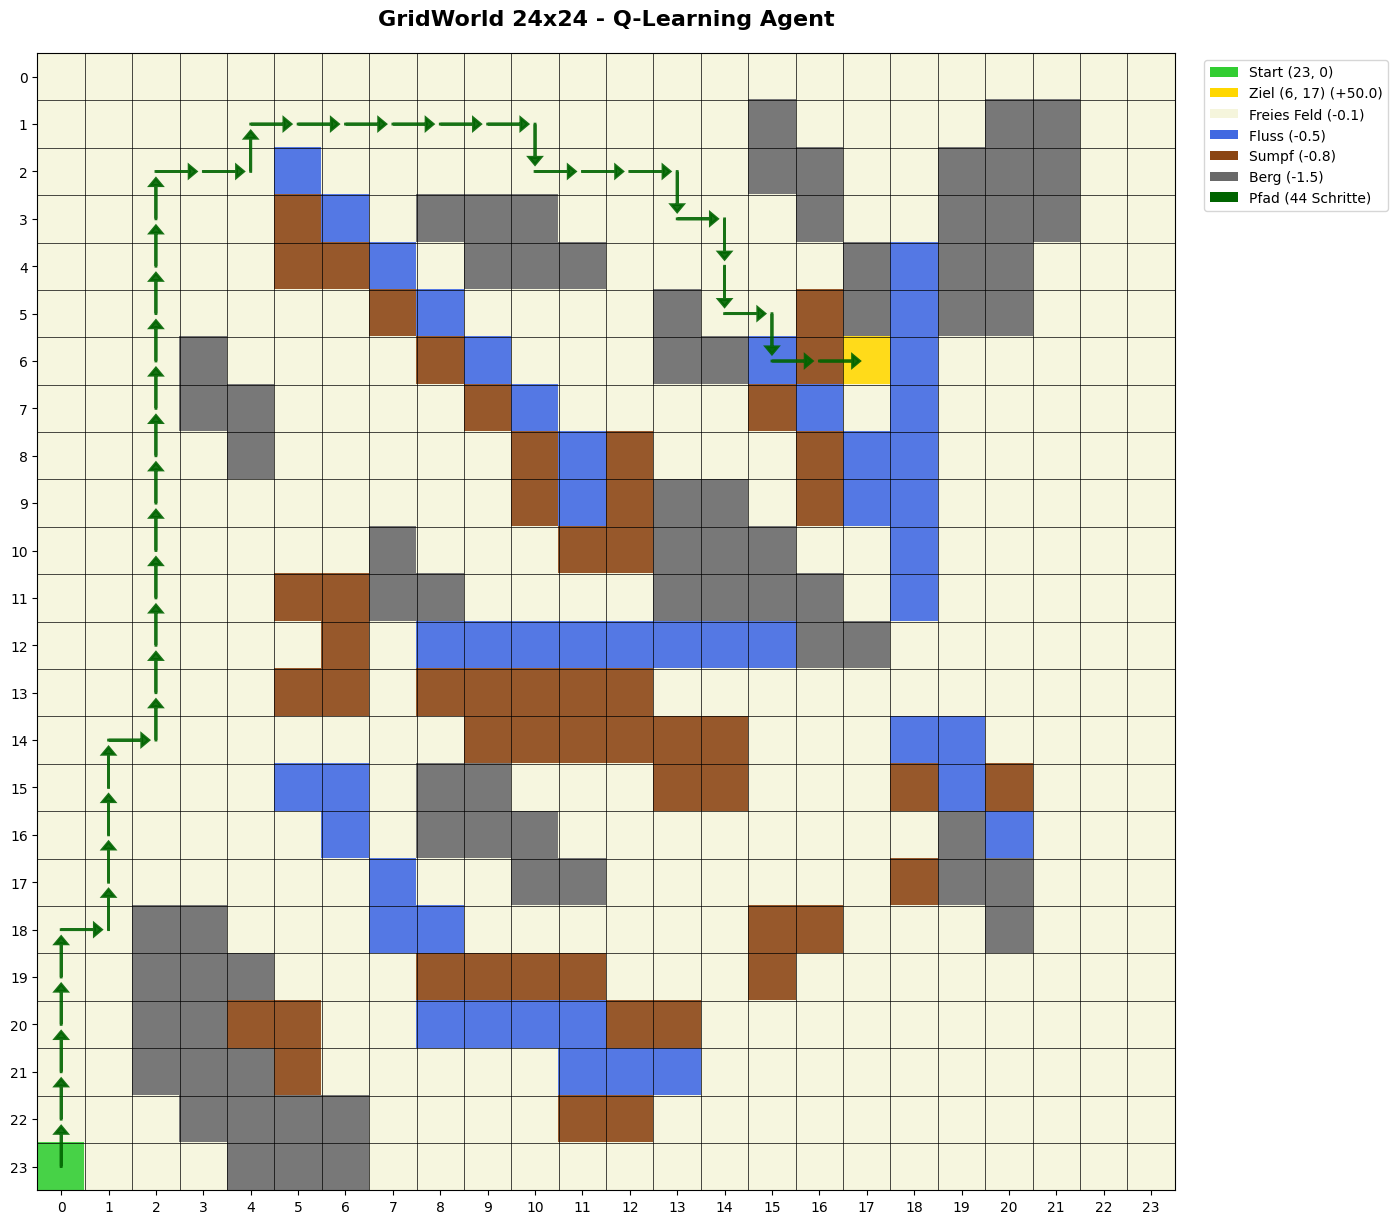


DQN AGENT
Path: [(23, 0), (23, 1), (22, 1), (21, 1), (20, 1), (19, 1), (18, 1), (17, 1), (17, 2), (16, 2), (15, 2), (14, 2), (14, 3), (14, 4), (13, 4), (12, 4), (11, 4), (10, 4), (9, 4), (9, 5), (9, 6), (9, 7), (8, 7), (8, 8), (8, 9), (8, 10), (8, 11), (7, 11), (7, 12), (7, 13), (7, 14), (7, 15), (7, 16), (7, 17), (6, 17)]
Actions: ['right', 'up', 'up', 'up', 'up', 'up', 'up', 'right', 'up', 'up', 'up', 'right', 'right', 'up', 'up', 'up', 'up', 'up', 'right', 'right', 'right', 'up', 'right', 'right', 'right', 'right', 'up', 'right', 'right', 'right', 'right', 'right', 'right', 'up']
Steps: 34
Path: [(23, 0), (23, 1), (22, 1), (21, 1), (20, 1), (19, 1), (18, 1), (17, 1), (17, 2), (16, 2), (15, 2), (14, 2), (14, 3), (14, 4), (13, 4), (12, 4), (11, 4), (10, 4), (9, 4), (9, 5), (9, 6), (9, 7), (8, 7), (8, 8), (8, 9), (8, 10), (8, 11), (7, 11), (7, 12), (7, 13), (7, 14), (7, 15), (7, 16), (7, 17), (6, 17)]
Actions: ['right', 'up', 'up', 'up', 'up', 'up', 'up', 'right', 'up', 'up', 'up', 'r

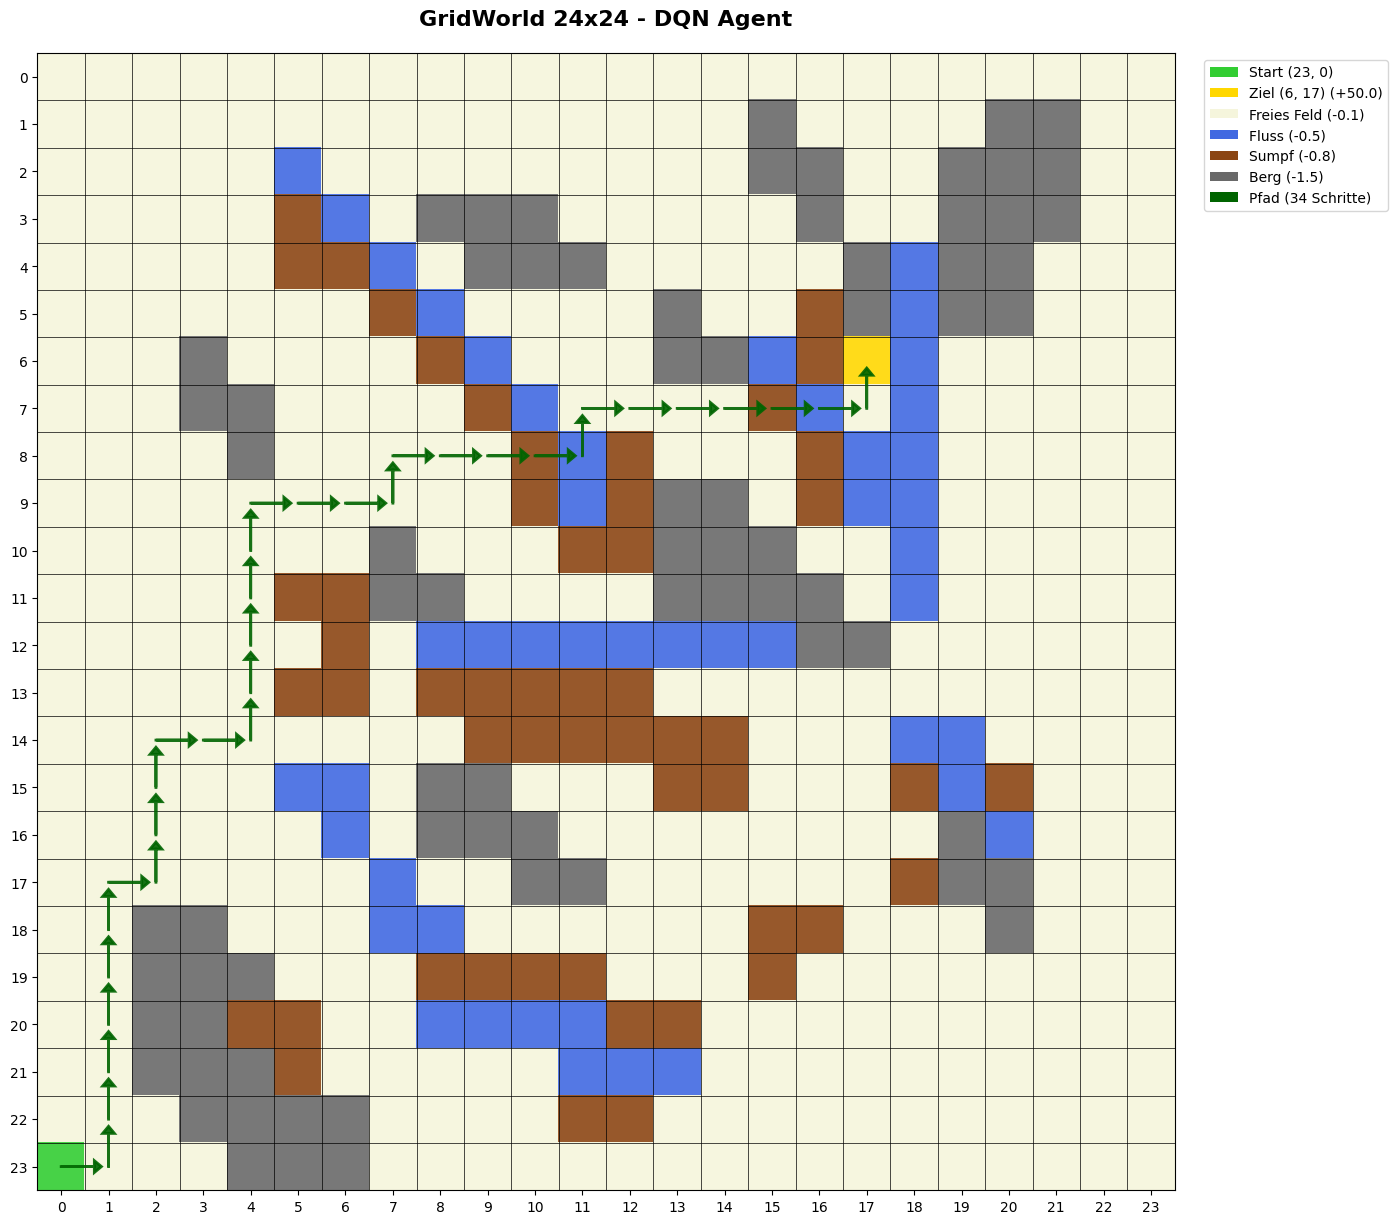

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

def visualize_gridworld(environment, agent=None, path_states=None, agent_name="Agent"):
    """
    Visualisiert das GridEnvironment mit Terrain und optimalem Pfad.
    
    Args:
        environment: GridEnvironment Instanz
        agent: Agent (optional) - wenn Q-Learning Agent, werden Q-Werte visualisiert
        path_states: Liste von States für optimalen Pfad (optional)
        agent_name: Name des Agenten für Titel
    """
    fig, ax = plt.subplots(figsize=(14, 14))
    
    # Grid-Matrix erstellen
    # 0: Frei, 1: Fluss, 2: Sumpf, 3: Berg, 4: Start, 5: Ziel
    grid = np.zeros(environment.shape)
    
    # Terrain-Typen eintragen
    for pos in environment.obstacles.river_positions:
        grid[pos] = 1
    for pos in environment.obstacles.swamp_positions:
        grid[pos] = 2
    for pos in environment.obstacles.mountain_positions:
        grid[pos] = 3
    
    # Start und Ziel
    start = environment.start_position
    goal = environment.goal_position
    grid[start] = 4
    grid[goal] = 5
    
    # Farbschema
    colors = [
        '#F5F5DC',  # 0: Beige (freies Feld)
        '#4169E1',  # 1: Blau (Fluss)
        '#8B4513',  # 2: Braun (Sumpf)
        '#696969',  # 3: Grau (Berg)
        '#32CD32',  # 4: Grün (Start)
        '#FFD700'   # 5: Gold (Ziel)
    ]
    cmap = ListedColormap(colors)
    
    # Grid visualisieren
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=5, alpha=0.9)
    
    # Pfad visualisieren (falls vorhanden)
    if path_states:
        for i in range(len(path_states) - 1):
            y1, x1 = path_states[i]
            y2, x2 = path_states[i + 1]
            
            ax.arrow(x1, y1, (x2 - x1) * 0.7, (y2 - y1) * 0.7, 
                    head_width=0.25, head_length=0.15, 
                    fc='darkgreen', ec='darkgreen', linewidth=2, alpha=0.9, zorder=10)
    
    # Grid-Linien
    ax.set_xticks(np.arange(-0.5, environment.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, environment.shape[0], 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)
    
    # Achsenbeschriftung
    ax.set_xticks(np.arange(0, environment.shape[1], 1))
    ax.set_yticks(np.arange(0, environment.shape[0], 1))
    
    # Terrain-Kosten für Legende
    tc = environment.reward_config.terrain_costs
    
    # Legende
    legend_elements = [
        mpatches.Patch(facecolor='#32CD32', label=f'Start {start}'),
        mpatches.Patch(facecolor='#FFD700', label=f'Ziel {goal} (+{environment.reward_config.goal_reward})'),
        mpatches.Patch(facecolor='#F5F5DC', label=f'Freies Feld ({tc.free})'),
        mpatches.Patch(facecolor='#4169E1', label=f'Fluss ({tc.river})'),
        mpatches.Patch(facecolor='#8B4513', label=f'Sumpf ({tc.swamp})'),
        mpatches.Patch(facecolor='#696969', label=f'Berg ({tc.mountain})')
    ]
    
    if path_states:
        legend_elements.append(mpatches.Patch(facecolor='darkgreen', label=f'Pfad ({len(path_states)-1} Schritte)'))
    
    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    ax.set_title(f'GridWorld 24x24 - {agent_name}', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

# Visualisierung Q-Learning Agent
print("=" * 60)
print("Q-LEARNING AGENT")
print("=" * 60)
states_q, actions_q = agent.path(state=env.start_position)
print(f"Path: {states_q}")
print(f"Actions: {actions_q}")
print(f"Steps: {len(states_q) - 1}")
visualize_gridworld(env, agent=agent, path_states=states_q, agent_name="Q-Learning Agent")

# Visualisierung DQN Agent
print("\n" + "=" * 60)
print("DQN AGENT")
print("=" * 60)
states_dqn, actions_dqn = dqnagent.path(state=env.start_position)
print(f"Path: {states_dqn}")
print(f"Actions: {actions_dqn}")
print(f"Steps: {len(states_dqn) - 1}")
visualize_gridworld(env, agent=None, path_states=states_dqn, agent_name="DQN Agent")